In [97]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

In [98]:
N = 16
M = 4
H_N = np.pi/N

R21 = 2
R22 = 1.5

ALPHA = 1e-4
BETA = 1e-4
GAMMA = 1e-4
KSI = 0.1
EPS = 1e-3 #in stopping criteria

In [99]:
def x1_ex(t):
    return np.array([0.5 * t, 0.5 * np.sin(1.5*t)])

def x1_deriv_ex(t):
    return np.array([0.5 * np.ones_like(t), 0.75 * np.cos(1.5*t)])

def x1_initial(t):
    return np.array([0.5 * t, 0.25 * t])

def x1_deriv_initial(t):
    return np.array([0.5 * np.ones_like(t), 0.25 * np.ones_like(t)])


def x1_tilde_ex(t):
    return x1_ex(np.cos(t))

def x1_tilde_deriv_ex(t):
    return x1_deriv_ex(np.cos(t))

def x1_tilde_initial(t):
    return x1_initial(np.cos(t))

def x1_tilde_deriv_initial(t):
    return x1_deriv_initial(np.cos(t))

In [100]:
def x2(t):
    return np.array([R21*math.cos(t), R22*math.sin(t)])

def x2_deriv1_mod(t):
    d_dt = np.array([-R21*math.sin(t), R22*math.cos(t)])
    return np.linalg.norm(d_dt)

def f2(x):
    return 1

def x1_tilde_deriv1_mod(x1_tilde_deriv1): #[\tilde{x_1}'_x, \tilde{x_1}'_y]
    return math.sqrt(x1_tilde_deriv1[0]**2 + x1_tilde_deriv1[1]**2)


def R(j, t_data):
    s = 0
    t_diff = t_data - H_N*j

    for m in range(1,N):
        s += (math.cos(m * (t_diff)) / m )

    Rj = (s + ((math.cos(N*(t_diff))) / (2*N))) / (-N)
    return Rj - 1 / (2*N)

def H11(s, sigma, x1_tilde_s, x1_tilde_sigma, x1_tilde_deriv1):
    if np.linalg.norm(x1_tilde_s - x1_tilde_sigma) < 1e-12:
        mod = x1_tilde_deriv1_mod(x1_tilde_deriv1)
        return np.log(2 / (np.e * mod))
    else:
        num = 2 * abs(np.cos(s) - np.cos(sigma))
        den = np.e * np.linalg.norm(x1_tilde_s - x1_tilde_sigma)
        return np.log(num / den)
    
def H12(x1_tilde_s, tau):
    return np.log(1 / np.linalg.norm(x1_tilde_s - x2(tau)))

def H21(t, x1_tilde_sigma):
    return np.log(1 / np.linalg.norm(x2(t) - x1_tilde_sigma))

def H22(t, tau):
    if abs(t - tau) < 1e-12:
        mod = x2_deriv1_mod(t)
        return 0.5 * np.log(1 / (np.e * (mod**2)))
    else:
        num = (4 / np.e) * (np.sin((t - tau) / 2)**2)
        den = np.linalg.norm(x2(t) - x2(tau))**2
        return 0.5 * np.log(num / den)
    


def FormMatr(x1_tilde, x1_tilde_deriv1):
    size = 4 * N
    matrix = np.zeros((size, size))
    
    for i in range(2 * N):
        si = H_N*i
        for j in range(2 * N):
            sj = H_N*j
            Rj = R(j,si)
            
            # Рівняння 1 (на Г1)
            # Коефіцієнти при mu1
            matrix[i, j] = 0.5 * (-0.5*Rj + (H11(si, sj, x1_tilde[i], x1_tilde[j], x1_tilde_deriv1[i]) / (2*N)))
            # Коефіцієнти при mu2
            matrix[i, j + 2*N] = H12(x1_tilde[i], sj) / (2*N)
            
            # Рівняння 2 (на Г2)
            # Коефіцієнти при mu1
            matrix[i + 2*N, j] = 0.5 * (H21(si, x1_tilde[j]) / (2*N))
            # Коефіцієнти при mu2
            matrix[i + 2 * N, j + 2 * N] = -0.5*Rj + (H22(si, sj) / (2*N))

    return matrix

def f2_parametr(t):
    return f2(x2(t))

def FormVector():
    vector = np.zeros(4*N)

    for k in range(2*N):
        tk = H_N*k
        vector[k] = 0
        vector[k + 2 * N] = f2_parametr(tk)
    return vector

def FormPhi(x1_tilde, x1_tilde_deriv1):
    A = FormMatr(x1_tilde, x1_tilde_deriv1)
    b = FormVector()
    return np.linalg.solve(A, b)

In [101]:
def x2_deriv1_coord(t, coord):
    if coord == 1:
        return -R21*math.sin(t)
    elif coord == 2:
        return R22*math.cos(t)

def x2_deriv2_coord(t, coord):
    if coord == 1:
        return -R21*math.cos(t)
    elif coord == 2:
        return -R22*math.sin(t)

def v(t):
    return np.array([x2_deriv1_coord(t,2), -x2_deriv1_coord(t,1)]) / x2_deriv1_mod(t)

def L21(t, x1_tilde_sigma): #tilde L21
    x_diff = x1_tilde_sigma - x2(t)
    return np.dot(x_diff, v(t)) / (np.linalg.norm(x_diff)**2)

def L22(t, tau):
    if abs(t-tau) < 1e-12:
        return ( x2_deriv2_coord(tau,1)*x2_deriv1_coord(t,2) - x2_deriv2_coord(tau,2)*x2_deriv1_coord(t,1)) / (2*(x2_deriv1_mod(t))**3)
    else:
        x_diff = x2(tau) - x2(t)
        return np.dot(x_diff, v(t)) / np.linalg.norm(x_diff)**2

In [102]:
def L(j, s):
    return np.cos(j*s)
  
def L_deriv(j, s):
    return -j*np.sin(j*s)

def A31_32(x1_tilde):
  matr31 = np.zeros((2*N, 2*N))
  matr32 = np.zeros((2*N, 2*N))

  for i in range(2*N):
    ti = H_N*i
    for j in range(2*N):
      tj = H_N*j
      matr31[i,j] = 0.5 * (L21(ti, x1_tilde[j]) / (2*N))
      matr32[i,j] = L22(ti, tj) / (2*N)
    matr32[i,i] += 1 / (2*x2_deriv1_mod(ti))
  return matr31, matr32

def A13_14(x1_tilde, x1_tilde_deriv1, phi):
  matr13 = np.zeros((2*N, M + 1))
  matr14 = np.zeros((2*N, M + 1))

  for i in range(2*N):
      ti = H_N*i
      x1_tilde_i = x1_tilde[i]

      for j in range (M + 1):
        s3 = 0
        s4 = 0
        for k in range (2*N):
          tk = H_N*k

          x1_tilde_k = x1_tilde[k]
          
          x1_tilde_norm = np.linalg.norm(x1_tilde_i - x1_tilde_k)

          Lj_ti = L(j, ti)

          term2_x = (x2(tk)[0] - x1_tilde_i[0]) / (np.linalg.norm(x1_tilde_i - x2(tk)) ** 2)
          term2_y = (x2(tk)[1] - x1_tilde_i[1]) / (np.linalg.norm(x1_tilde_i - x2(tk)) ** 2)

          if x1_tilde_norm < 1e-12:
            x1_tilde_deriv_k = x1_tilde_deriv1[k]
            x1_tilde_deriv1_mod_val = x1_tilde_deriv1_mod(x1_tilde_deriv_k)

            term1_x = - 0.5 * ((x1_tilde_deriv_k[0] * L_deriv(j, tk)) / (x1_tilde_deriv1_mod_val ** 2))
            term1_y = - 0.5 * ((x1_tilde_deriv_k[1] * L_deriv(j, tk)) / (x1_tilde_deriv1_mod_val ** 2))
            
            s3 += phi[k] * term1_x + phi[k + 2*N] * Lj_ti * term2_x
            s4 += phi[k] * term1_y + phi[k + 2*N] * Lj_ti * term2_y
          else:
            L_difference = L(j, tk) - Lj_ti

            term1_x = 0.5 * ((L_difference * (x1_tilde_i[0] - x1_tilde_k[0])) / (x1_tilde_norm ** 2))
            term1_y = 0.5 * ((L_difference * (x1_tilde_i[1] - x1_tilde_k[1])) / (x1_tilde_norm ** 2))

            s3 += phi[k] * term1_x + phi[k + 2*N] * Lj_ti * term2_x
            s4 += phi[k] * term1_y + phi[k + 2*N] * Lj_ti * term2_y

        matr13[i,j] = s3 / (2*N)
        matr14[i,j] = s4 / (2*N)
  return matr13, matr14

def A23_24_33_34(x1_tilde, phi):
  matr23 = np.zeros((2*N, M+1))
  matr24 = np.zeros((2*N, M+1))
  matr33 = np.zeros((2*N, M+1))
  matr34 = np.zeros((2*N, M+1))

  for i in range(2*N):
    ti = H_N*i

    for j in range (M+1):
      s23 = 0
      s24 = 0
      s33 = 0
      s34 = 0
      for k in range (2*N):
        tk = H_N*k

        x1_tilde_k = x1_tilde[k]

        s23 += 0.5 * phi[k] * L(j, tk) * ((x2(ti)[0] - x1_tilde_k[0]) / (np.linalg.norm(x2(ti) - x1_tilde_k) ** 2))
        s24 += 0.5 * phi[k] * L(j, tk) * ((x2(ti)[1] - x1_tilde_k[1]) / (np.linalg.norm(x2(ti) - x1_tilde_k) ** 2))

        s33 += 0.5 * phi[k] * L(j, tk) * ((v(ti)[0] - 2*L21(ti, x1_tilde_k) * (x1_tilde_k[0] - x2(ti)[0])) / (np.linalg.norm(x1_tilde_k - x2(ti)) ** 2))
        s34 += 0.5 * phi[k] * L(j, tk) * ((v(ti)[1] - 2*L21(ti, x1_tilde_k) * (x1_tilde_k[1] - x2(ti)[1])) / (np.linalg.norm(x1_tilde_k - x2(ti)) ** 2))
      matr23[i,j] = s23/(2*N)
      matr24[i,j] = s24/(2*N)
      matr33[i,j] = s33/(2*N)
      matr34[i,j] = s34/(2*N)
  return matr23, matr24, matr33, matr34

def B_1(x1_tilde, x1_tilde_deriv1, phi):
  vector = np.zeros(2*N)

  for i in range (2*N):
    si = H_N*i
    s = 0
    for j in range (2*N):
      tj = H_N*j
      s += (
        0.5 * phi[j] * (-0.5 * R(j, si) + (H11(si, tj, x1_tilde[i], x1_tilde[j], x1_tilde_deriv1[j]) / (2*N)))
        + phi[j + 2*N] * (H12(x1_tilde[i], tj) / (2*N))
      )
    vector[i] = -s
  return vector
  
def B_2(x1_tilde, phi):
  vector = np.zeros(2*N)

  for i in range (2*N):
    ti = H_N*i
    s = 0
    for j in range (2*N):
      tj = H_N*j
      s += (
        0.5 * phi[j] * (H21(ti, x1_tilde[j]) / (2*N)) 
        + phi[j + 2*N] * (-0.5 * R(j, ti) + (H22(ti, tj) / (2*N)))
      )
    vector[i] = f2_parametr(ti) - s
  return vector

def B_3(x1_tilde, phi, g2):
  vector = np.zeros(2*N)

  for i in range (2*N):
    ti = H_N*i
    s=0
    for j in range (2*N):
      tj = H_N*j
      s += 0.5 * phi[j] * L21(ti, x1_tilde[j]) + phi[j + 2*N] * L22(ti, tj)
    vector[i] = g2[i] - (0.5 * phi[i + 2*N]) / x2_deriv1_mod(ti) - s/(2*N)
  return vector

def diag_matrix():
    d = np.ones(4*N + 2*M + 2)
    
    d[: 2*N] = ALPHA
    d[2*N : 4*N] = BETA
    d[4*N : ] = GAMMA * (np.pi / 2)

    d[4*N] = GAMMA * np.pi
    d[4*N + M + 1] = GAMMA * np.pi
    
    return np.diag(d)

def Coeff(x1_tilde, x1_tilde_deriv1, phi, g2):
  matr11_12_21_22 = FormMatr(x1_tilde, x1_tilde_deriv1)
  matr31, matr32 = A31_32(x1_tilde)
  matr13, matr14 = A13_14(x1_tilde, x1_tilde_deriv1, phi)
  matr23, matr24, matr33, matr34 = A23_24_33_34(x1_tilde, phi)

  matr13_14_23_24 = np.block([[matr13, matr14], [matr23, matr24]])
  matr31_32 = np.hstack((matr31, matr32))
  matr33_34 = np.hstack((matr33, matr34))
  big_matrix = np.block([[matr11_12_21_22, matr13_14_23_24], [matr31_32, matr33_34]])
  big_matrix_transposed = big_matrix.T

  final_matrix = diag_matrix() + np.dot(big_matrix_transposed, big_matrix)

  vector1 = B_1(x1_tilde, x1_tilde_deriv1, phi)
  vector2 = B_2(x1_tilde, phi)
  vector3 = B_3(x1_tilde, phi, g2)

  big_vector = np.hstack((vector1, vector2, vector3)) 
  final_vector = np.dot(big_matrix_transposed, big_vector)

  return np.linalg.solve(final_matrix, final_vector)


def gamma_element(s, gamma_coeffs): #gamma_x or gamma_y for specific s
  j_array = np.arange(M+1)

  arr = L(j_array, s)

  return np.dot(gamma_coeffs, arr)
gamma_element_vectorized = np.vectorize(gamma_element, excluded=['gamma_coeffs'])

def gamma_element_deriv1(s, gamma_coeffs): 
  j_array = np.arange(M+1)

  arr = L_deriv(j_array, s)

  return np.dot(gamma_coeffs, arr)
gamma_element_deriv1_vectorized = np.vectorize(gamma_element_deriv1, excluded=['gamma_coeffs'])

def gamma_func(s_array, gamma_coeffs):
  gamma_x_array = gamma_element_vectorized(s_array, gamma_coeffs = gamma_coeffs[:M+1])
  gamma_y_array = gamma_element_vectorized(s_array, gamma_coeffs = gamma_coeffs[M+1:])

  return np.column_stack((gamma_x_array, gamma_y_array))

def gamma_deriv1_func(s_array, gamma_coeffs): 
  gamma_x_deriv_array = gamma_element_deriv1_vectorized(s_array, gamma_coeffs = gamma_coeffs[:M+1])
  gamma_y_deriv_array = gamma_element_deriv1_vectorized(s_array, gamma_coeffs = gamma_coeffs[M+1:])

  return np.column_stack((gamma_x_deriv_array, gamma_y_deriv_array))

In [103]:
def l2_norm_gamma(gamma_coeffs):
    gx = gamma_coeffs[:M+1]
    gy = gamma_coeffs[M+1:]
    
    norm_sq_x = np.pi * gx[0]**2 + (np.pi/2) * np.sum(gx[1:]**2)
    norm_sq_y = np.pi * gy[0]**2 + (np.pi/2) * np.sum(gy[1:]**2)
    
    return np.sqrt(norm_sq_x + norm_sq_y)

def l2_norm_x1_tilde(x1_tilde):
    norm_sq = H_N * np.sum(x1_tilde[:, 0]**2 + x1_tilde[:, 1]**2)
    return np.sqrt(norm_sq)

def stopping_criterion(gamma_coeffs, x1_tilde):
    return l2_norm_gamma(gamma_coeffs) / l2_norm_x1_tilde(x1_tilde)

def l2_norm(arr):
    return math.sqrt(H_N*sum(arr**2))

In [104]:
def norm_deriv_app(x1_tilde, phi, i):
  s = 0
  ti = i*H_N

  for j in range(2*N):
    tj = j*H_N
    s += 0.5 * phi[j] * L21(ti, x1_tilde[j]) + phi[j + 2*N] * L22(ti, tj)

  return (0.5 * phi[i + 2*N]) / x2_deriv1_mod(ti) + s / (2*N)

def g2(x1_tilde, x1_tilde_deriv1):
  phi = FormPhi(x1_tilde, x1_tilde_deriv1)

  vector = np.zeros(2*N)

  for i in range(2*N):
    vector[i] = norm_deriv_app(x1_tilde,phi,i)
  return vector

In [105]:
t_array = H_N*np.arange(2*N)

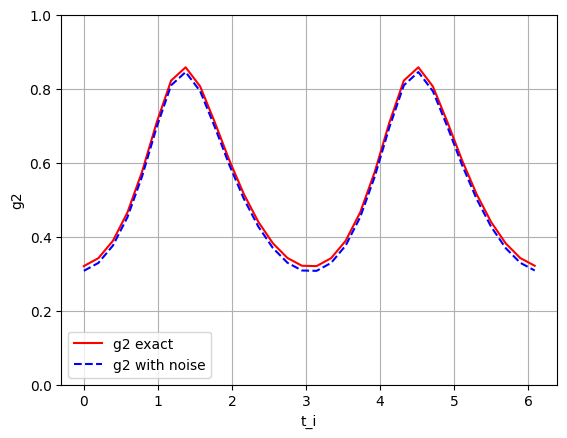

In [106]:
x1_tilde_ex_matrix = x1_tilde_ex(t_array).T
x1_tilde_deriv_ex_matrix = x1_tilde_deriv_ex(t_array).T
g2_flux = g2(x1_tilde_ex_matrix, x1_tilde_deriv_ex_matrix)
g2_flux

delta = 0.05
rand_num = random.uniform(0,1)
rand_num = 0.41
g2_flux_delta = g2_flux + delta*(2*rand_num - 1)*l2_norm(g2_flux)

plt.plot(t_array, g2_flux, color = 'red', linestyle='-', label='g2 exact')
plt.plot(t_array, g2_flux_delta, color = 'blue', linestyle='--', label='g2 with noise')

plt.xlabel('t_i')
plt.ylabel('g2')
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

In [107]:
iteration = 0
criteria = []
errs = []

x1_tilde = x1_tilde_initial(t_array).T
x1_tilde_deriv1 = x1_tilde_deriv_initial(t_array).T

varphi = FormPhi(x1_tilde, x1_tilde_deriv1)

while(True):
    coeffs = Coeff(x1_tilde, x1_tilde_deriv1, varphi, g2_flux_delta)
    phi, gamma_coeffs = np.split(coeffs, [4*N])
    gamma = gamma_func(t_array, gamma_coeffs)

    x1_tilde = x1_tilde + KSI*gamma
    varphi = varphi + phi
    x1_tilde_deriv1 = x1_tilde_deriv1 + KSI*gamma_deriv1_func(t_array, gamma_coeffs)
    
    iteration += 1
    crit = stopping_criterion(gamma_coeffs, x1_tilde)
    criteria.append(crit)
    err = l2_norm_x1_tilde(x1_tilde - x1_tilde_ex(t_array).T)
    errs.append(err)

    if crit < EPS:
        print(f"Реконструкція завершена!")
        break

Реконструкція завершена!


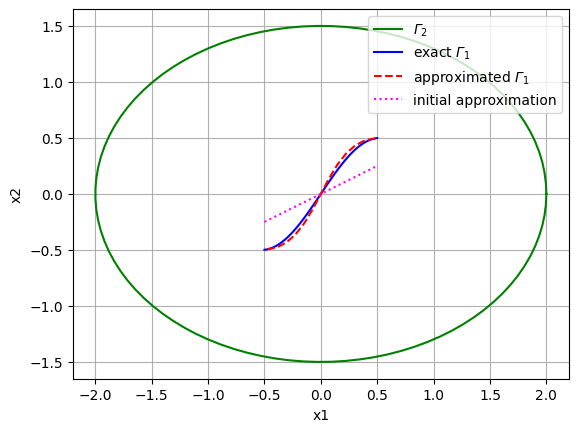

In [108]:
theta = np.linspace(-1, 1)
theta_100 = np.linspace(0, 2*np.pi, 100)

x1_ex_vals = x1_ex(theta)

x1_app_vals = x1_tilde[:N, :].T

x2_vals = np.array([R21*np.ones_like(theta_100)*np.cos(theta_100), R22*np.ones_like(theta_100)*np.sin(theta_100)])

x1_initial_vals = x1_initial(theta)

plt.plot(x2_vals[0],         x2_vals[1],         color='green',   linestyle='-',      label='$Г_2$')
plt.plot(x1_ex_vals[0],      x1_ex_vals[1],      color='blue',    linestyle='-',      label='exact $Г_1$')
plt.plot(x1_app_vals[0],     x1_app_vals[1],     color='red',     linestyle='--',     label='approximated $Г_1$')
plt.plot(x1_initial_vals[0], x1_initial_vals[1], color='magenta', linestyle='dotted', label='initial approximation')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

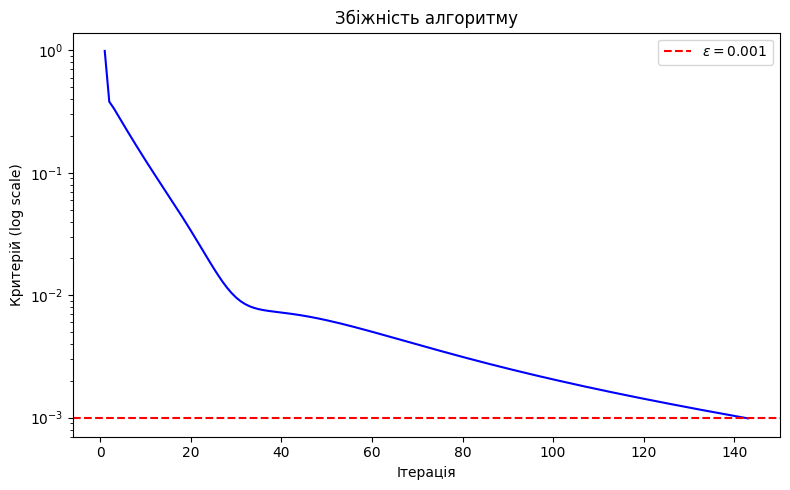

In [110]:
plt.figure(figsize=(8, 5))
plt.semilogy(range(1, len(criteria) + 1), criteria, color='blue', linewidth=1.5)
plt.axhline(y=EPS, color='red', linestyle='--', label=f'$\epsilon = {EPS}$')
plt.xlabel('Ітерація')
plt.ylabel('Критерій (log scale)')
plt.title('Збіжність алгоритму')
plt.legend()
plt.tight_layout()
plt.show()